In [9]:
import qiskit
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit import Parameter

In [10]:
def make_circuit(t1, t2, t3):
    qc = QuantumCircuit(1, 1)
    # qc.h(0)
    qc.rx(t1, 0)
    qc.ry(t2, 0)
    qc.rz(t3, 0)
    qc.rx(t1, 0)
    qc.ry(t2, 0)
    qc.rz(t3, 0)
    # qc.h(0)
    qc.measure(0, 0)
    return qc

In [38]:
def run(qc, shots=2**24):
    backend = Aer.get_backend('qasm_simulator')
    job_sim = execute(qc,backend,shots=shots)
    result_sim = job_sim.result()
    counts = result_sim.get_counts()
    return 0 if '1' not in counts else counts['1'] / shots

In [21]:
t1, t2, t3 = 1.5, 2.5, 3.5

In [22]:
qc = make_circuit(t1, t2, t3)
o = run(qc)
print(o)

0.7490987777709961


In [28]:
delta = 0.3
d1 = run(make_circuit(t1+delta, t2, t3))
d2 = run(make_circuit(t1, t2+delta, t3))
d3 = run(make_circuit(t1, t2, t3+delta))
print(d1, d2, d3)
g = [(d1-o) / delta, (d2-o) / delta, (d3-o) / delta]
print(g)

0.7936793565750122 0.8705134391784668 0.6106430292129517
[0.1486019293467204, 0.40471553802490234, -0.46151916186014813]


In [24]:
import math

s = math.pi/2
d1 = run(make_circuit(t1+s, t2, t3)) - run(make_circuit(t1-s, t2, t3))
d2 = run(make_circuit(t1, t2+s, t3)) - run(make_circuit(t1, t2-s, t3))
d3 = run(make_circuit(t1, t2, t3+s)) - run(make_circuit(t1, t2, t3-s))
g = [d1 / 2, d2 / 2, d3 / 2]
print(g)

[0.15988650918006897, 0.4189259111881256, -0.4307509660720825]


In [43]:
import numpy as np

x = np.array(range(100)) / 10
y = []

for t in x:
    qc = QuantumCircuit(1, 1)
    qc.rx(t, 0)
    qc.measure(0, 0)

    result = run(qc, shots=2**20)
    y.append(result)

y = np.array(y)
print(y)

[0.         0.02453518 0.09548569 0.20577812 0.34541702 0.49983883
 0.65427399 0.79434872 0.90443707 0.97538471 1.         0.97572517
 0.90497017 0.79394817 0.65467358 0.49992466 0.34541988 0.20658112
 0.09581375 0.02449608 0.         0.02442169 0.09547234 0.20583916
 0.34536552 0.49925804 0.65468311 0.79380417 0.90478039 0.97537899
 1.         0.97548866 0.9044323  0.79338646 0.65469456 0.50037766
 0.34530067 0.20626926 0.09590435 0.02458668 0.         0.0243082
 0.09492874 0.2057991  0.34501839 0.49936771 0.6548233  0.7931366
 0.90430069 0.97558117 1.         0.97553635 0.90380192 0.79340553
 0.65493107 0.50033951 0.34531689 0.20575714 0.09579563 0.02459335
 0.         0.02468586 0.09522247 0.20560265 0.3459425  0.49976921
 0.65517139 0.79361057 0.90450382 0.97570705 1.         0.97544575
 0.90456104 0.79367161 0.65447044 0.50205231 0.34480095 0.20641804
 0.09516525 0.0243597  0.         0.02454472 0.09555817 0.2052002
 0.34599781 0.50035    0.65403271 0.79535675 0.90443611 0.9753646

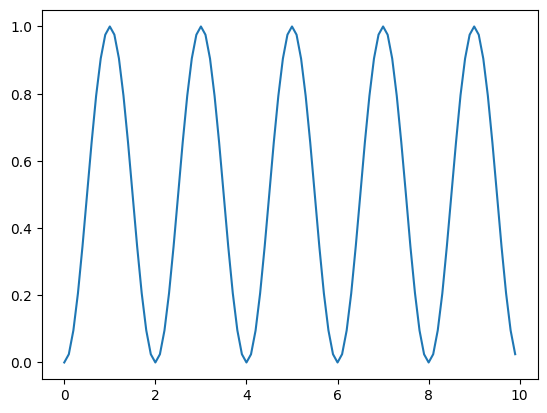

In [44]:
import matplotlib.pyplot as plt

plt.plot(x, y)

In [ ]:
y = (np.cos(x * np.pi) - 1) / -2
y * -2 = np.cos(x * np.pi) - 1
y * -2 + 1 = np.cosx


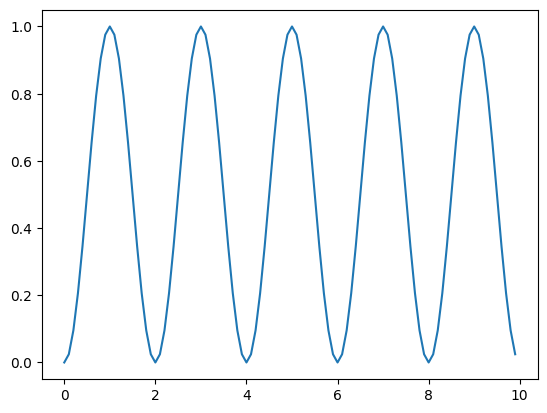

In [59]:
plt.plot(x, (np.cos(x) - 1) / -2)

In [68]:
qc = QuantumCircuit(1, 1)
qc.rx(np.arccos(0.7 * -2 + 1), 0)
qc.measure(0, 0)

result = run(qc, shots=2**20)
print(result)

0.6997404098510742
